In [1]:
import time                      #libreria per cronometrare
import matplotlib.pyplot as plt  #libreria per graficare i risultati

import torch                     #libreria per il pytorch
import torch.nn as nn            #per costruire la rete neurale
import torch.optim as optim      #per utilizzare il metodo del gradient descent
from torch.utils.data import DataLoader      #prendere il dataset e dividerlo in batch
from torchvision import datasets, transforms #datasets: per organizzare i dati (lo uso per associare le immagini con le corrispettiva ettichetta)
                                             #transform: prepara le immagini prima di passarla alla rete

In [15]:
#percorso del datasets
path = "kagglehub"

dir_training = path+"/seg_train"  #percorso dati TRAINING
dir_validation = path+"/seg_test" #percorso dati TEST

In [16]:
# Inizializzazione dati
IMG_SIZE = (150, 150)  #dim. immagine
BATCH_SIZE = 64        #dim. batch
EPOCH = 30             #n. epoch
seed = 67              #seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #su device verrà scritto se viene usato la GPU ("cuda") se disponibile oppure la CPU
print("Device usato:", device)

torch.manual_seed(seed)  #impostazione seed per CPU
if torch.cuda.is_available():  #impostazione seed se viene utilizzato GPU
    torch.cuda.manual_seed_all(seed)

Device usato: cuda


In [17]:
#definisco il tipo di trasformazione alle immagini

#trasformazione per le immagini destinati al training
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),           #impostazione immagini a dim. 150x150 (rimuovibile dato che le immagini sono già tutte di dim. 150x150)
    transforms.RandomHorizontalFlip(),     #rotazione dell'immagine rispetto l'asse orizzonatle (per diminuire l'ovverfitting)
    transforms.RandomRotation(degrees=70), #rotazione dell'immagine fra 70 gradi  (per diminuire l'ovverfitting)
    transforms.ToTensor()                  #rescaling 1./255 (ottengo valori fra 0 e 1 invece di 0 a 255)
])

#trasformazione per le immagini destinati al test
validation_transform = transforms.Compose([ 
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

In [18]:
#per ottenere le coppie (immagine, classe di appartenenza) da
training_dataset = datasets.ImageFolder(
    root=dir_training,              #posizione cartella training
    transform=train_transform       #tipo di trasformazione per il training
)
validation_dataset = datasets.ImageFolder(
    root=dir_validation,            #posizione cartella test
    transform=validation_transform  #tipo di trasformazione per il test
)

classi = training_dataset.classes #ottiene tutti tipi di classificazione
print(classi)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [6]:
training_data = DataLoader(
    training_dataset,       #le coppie (immagine, classe di appartenenza)
    batch_size=BATCH_SIZE,  #divisione di immagini in porzioni di dim. BATCH_SIZE=64
    shuffle=True,           #mischia le immagini
)

validation_data = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [7]:
#rete convoluzionale

#creazione di una classe rete neurale che eredità la classe nn.Module
class CNN(nn.Module):            
    def __init__(self, num_classes):  #il metodo definisce le componenti della struttura neurale
        super().__init__()            #inizializzare correttamente la classe padre nn.Module

        #il primo strato convoluzionale: 
        # *input: canali di input RGB 
        # *output: il numero di feature map
        # *kernel_size=3 indica dim. filtro 3x3
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)   #di default padding="valid"
        #il filtro trasforma in input un'immagine 3x150x150 ==> in 32x148x148
        #dove 32 è il numero di filtri
        #148 dal filtro che scorre l’immagine rimanendo sempre completamente dentro (per il paramaetro padding="valid")

        #nota: lo strato di input su Pytorch è già definità quando riceve l'immagine quindi 
        #      il primo strato convoluzionale essere inserito in input il numero di canali RGB 
        
        #altri due strati convoluzionali:
        # *input: feature map dello strato precedente
        # *output: il numero di feature map
        # *kernel_size=3 indica dim. filtro 3x3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)

        #diminuisce la dim. della feature map
        #tutta la feature map viene divisa in partizioni da 2x2 e
        #ogni partizione viene salvata la feature con il valore più alto
        #es 2x2   [3 8]
        #         [1 4]      ==> elemento n della feature map = 8
        self.pool = nn.MaxPool2d(kernel_size=2)
        
        #trasforma le feature map (matrice) in un vettore monodimensionale
        self.flatten = nn.Flatten()

        #durante il training viene spento casualmente il 30% dei neuroni per evitare l'ovverfitting
        self.dropout = nn.Dropout(0.3)         


        #strati per classificare le immagini dalle feature map
        
        #dopo i strati convoluzionali e pooling l'input viene determinato dal commento "!!!" nel metodo foward
        #il secondo parametro è l'output dello strato neurale
        self.fc1 = nn.Linear(128*17*17, 64)

        #strato finale per la classificazione
        self.fc2 = nn.Linear(64, num_classes) 

    
    #struttura feedfoward
    def forward(self, x):
        #entra un immagine 3x150x150
        
        x = self.pool(torch.relu(self.conv1(x)))
        #self.conv1(x) viene creato una feature map da 32x148x148
        #torch.relu() viene impostato la funzione di attivazione
        #pool() dimezza la feature map e da 32x74x74
        
        x = self.pool(torch.relu(self.conv2(x)))
        #self.conv1(x) viene creato una feature map da 64x72x72
        #torch.relu() viene impostato la funzione di attivazione
        #pool() dimezza la feature map e da 32x36x36
        
        x = self.pool(torch.relu(self.conv3(x)))
        #self.conv1(x) viene creato una feature map da 128x34x34
        #torch.relu() viene impostato la funzione di attivazione
#COMMENTO "!!!":  #pool() dimezza la feature map e da 128x17x17              

        #trasformazione feature in un vettore monodimensionale
        x = self.flatten(x) 

        #primo strato con attivazione relu
        x = torch.relu(self.fc1(x))

        #spegne il 30% dei neuroni dello strato precedente
        x = self.dropout(x)

        #strato che determina la classificazione (funzione softmax incluso nel nn.CrossEntropyLoss())
        x = self.fc2(x)

        return x




model = CNN(num_classes=len(classi)).to(device)  #creazione della rete convoluzionale

criterion = nn.CrossEntropyLoss()           #la funzione di costo (questo pezzo include l'utilizzo della funzione di attivazione softmax)
optimizer = optim.Adam(model.parameters())  #il tipo di ottimizzatore per la gradient descent
print(model)  #stampa la struttura feedfoward della rete (sarebbe il metodo "def forward" della classe)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=36992, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=6, bias=True)
)


In [8]:
#funzione per il training delle immagini
def training(model, dataloader, criterion, optimizer, device):  #per 1 epoch
    model.train()  #addestramento modello (viene attivato il dropout)

    loss_total = 0.0  #errore totale della batch
    n_correct = 0     #numero di immagini corretti
    img_total = 0     #il numero di immagini analizzate nella batch

    for images, labels in dataloader: #images => le immagini , labels => la classe di appartenenza dell'immagine
        images = images.to(device)    #viene caricato le immagini sulla GPU/CPU e la variabile punta alla posizione di memoria sulla GPU/CPU
        labels = labels.to(device)    #stessa cosa per l'etichetta 

        optimizer.zero_grad() 

        outputs = model(images)           #risultato del modello
        loss = criterion(outputs, labels) #viene determinato il loss, quindi il divario fra il vero risultato e il risultato del modello
        loss.backward()                   #determina gradiente
        optimizer.step()                  #aggiorna pesi usando il gradiente

        
        loss_total += loss.item() * images.size(0)      #media errore batch * numero immagini della batch => loss totale
        _, predicted = torch.max(outputs, dim=1)        #valore della classe predetta
        img_total += labels.size(0)                     #numero di immagini + numero immagini della batch
        n_correct += (predicted == labels).sum().item() #numero di immagini predette bene

    epoch_loss = loss_total / img_total    #loss
    epoch_accuracy = n_correct / img_total #accuracy

    return epoch_loss, epoch_accuracy


#funzione per il validation test delle immagini
def evaluate(model, dataloader, criterion, device):  #per 1 epoch
    model.eval()  #test modello  (viene disattivato il dropout)

    loss_total = 0.0  #errore totale della batch
    n_correct = 0     #numero di immagini corretti
    img_total = 0     #il numero di immagini analizzate nella batch

    with torch.no_grad(): #impedisce l'aggiornamento dei pesi durante il test
        for images, labels in dataloader: #images => le immagini , labels => la classe di appartenenza dell'immagine
            images = images.to(device)    #viene caricato le immagini sulla GPU/CPU e la variabile punta alla posizione di memoria sulla GPU/CPU
            labels = labels.to(device)    #stessa cosa per l'etichetta 

            outputs = model(images)             #output modello
            loss = criterion(outputs, labels)   #loss del modello

            loss_total += loss.item() * images.size(0)      #media errore batch * numero immagini della batch => loss totale
            _, predicted = torch.max(outputs, dim=1)        #valore della classe predetta
            img_total += labels.size(0)                     #numero di immagini + numero immagini della batch
            n_correct += (predicted == labels).sum().item() #numero di immagini predette bene

    epoch_loss = loss_total / img_total    #loss
    epoch_accuracy = n_correct / img_total #accuracy

    return epoch_loss, epoch_accuracy

In [9]:
#salvo nella matrice history le accuracy e loss di tutte le epoch per il graficare l'appredimento
history = {
    "accuracy": [],
    "val_accuracy": [],
    "loss": [],
    "val_loss": []
}

start_time = time.time() #cronometrare il tempo

for epoch in range(EPOCH):
    train_loss, train_accuracy = training(model, training_data, criterion, optimizer, device) #training
    val_loss, val_accuracy = evaluate(model, validation_data, criterion, device)              #test

    #registrazione della accuracy e loss
    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    #stampa dei valori di accuracy e loss per il training e test
    print(
        f"Epoch {epoch + 1}/{EPOCH} - ",
        f"accuracy: {train_accuracy:.4f} - loss: {train_loss:.4f} - ",
        f"val_accuracy: {val_accuracy:.4f} - val_loss: {val_loss:.4f}"
    )

print("training time:", time.time() - start_time)

Epoch 1/30 -  accuracy: 0.4998 - loss: 1.2517 -  val_accuracy: 0.6280 - val_loss: 0.9794
Epoch 2/30 -  accuracy: 0.6059 - loss: 1.0345 -  val_accuracy: 0.6557 - val_loss: 0.9060
Epoch 3/30 -  accuracy: 0.6535 - loss: 0.9338 -  val_accuracy: 0.6953 - val_loss: 0.7947
Epoch 4/30 -  accuracy: 0.6667 - loss: 0.9005 -  val_accuracy: 0.7070 - val_loss: 0.7613
Epoch 5/30 -  accuracy: 0.6828 - loss: 0.8578 -  val_accuracy: 0.7090 - val_loss: 0.7765
Epoch 6/30 -  accuracy: 0.6898 - loss: 0.8377 -  val_accuracy: 0.7257 - val_loss: 0.7488
Epoch 7/30 -  accuracy: 0.7056 - loss: 0.8015 -  val_accuracy: 0.7607 - val_loss: 0.6621
Epoch 8/30 -  accuracy: 0.7086 - loss: 0.7804 -  val_accuracy: 0.7453 - val_loss: 0.6843
Epoch 9/30 -  accuracy: 0.7246 - loss: 0.7578 -  val_accuracy: 0.7663 - val_loss: 0.6315
Epoch 10/30 -  accuracy: 0.7427 - loss: 0.7213 -  val_accuracy: 0.7763 - val_loss: 0.6132
Epoch 11/30 -  accuracy: 0.7431 - loss: 0.7157 -  val_accuracy: 0.7913 - val_loss: 0.5955
Epoch 12/30 -  accu

In [14]:
# Salva i pesi del modello (per scelta progettuale)
torch.save(model.state_dict(), "Modello/model_PyTorch.pth")

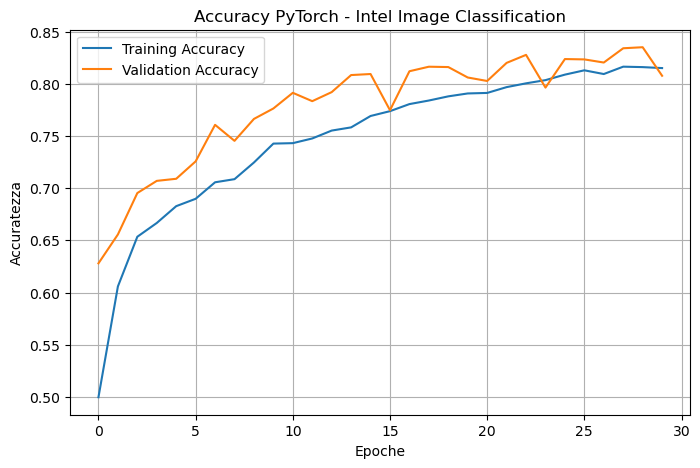

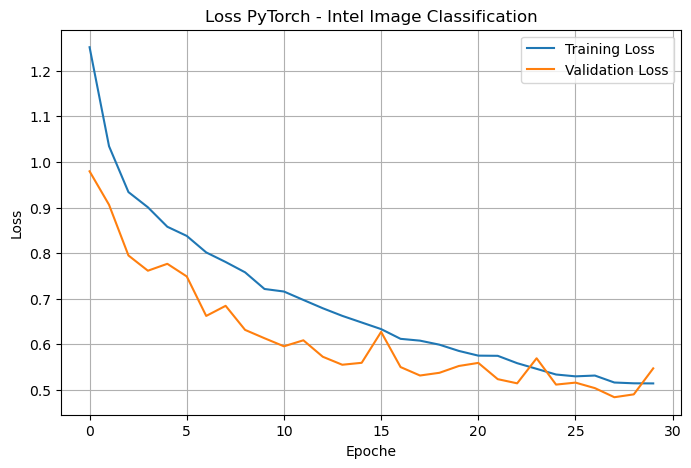

In [13]:
#plot del grafico 

# Accuracy
plt.figure(figsize=(8,5))

plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy PyTorch - Intel Image Classification')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')

plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))

plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')

plt.title('Loss PyTorch - Intel Image Classification')
plt.xlabel('Epoche')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.show()